In [2]:
# === IMPORTS ===
import torch
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

# === DRIVE ===
from google.colab import drive
drive.mount('/content/drive')

# === KAGGLE + DATASET ===
from google.colab import userdata
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_TOKEN')
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q -o brain-tumor-mri-dataset.zip -d /content/data
print("Dataset ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:01<00:00, 164MB/s]

Dataset ready!


In [3]:
import os
for root, dirs, files in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    print('  ' * level + os.path.basename(root) + '/')

data/
  Training/
    glioma/
    pituitary/
    notumor/
    meningioma/
  Testing/
    glioma/
    pituitary/
    notumor/
    meningioma/


In [4]:
import os

base_path = '/content/data/Training'
classes = os.listdir(base_path)

for cls in classes:
    cls_path = os.path.join(base_path, cls)
    num_images = len(os.listdir(cls_path))
    print(f"{cls}: {num_images} images")

glioma: 1400 images
pituitary: 1400 images
notumor: 1400 images
meningioma: 1400 images


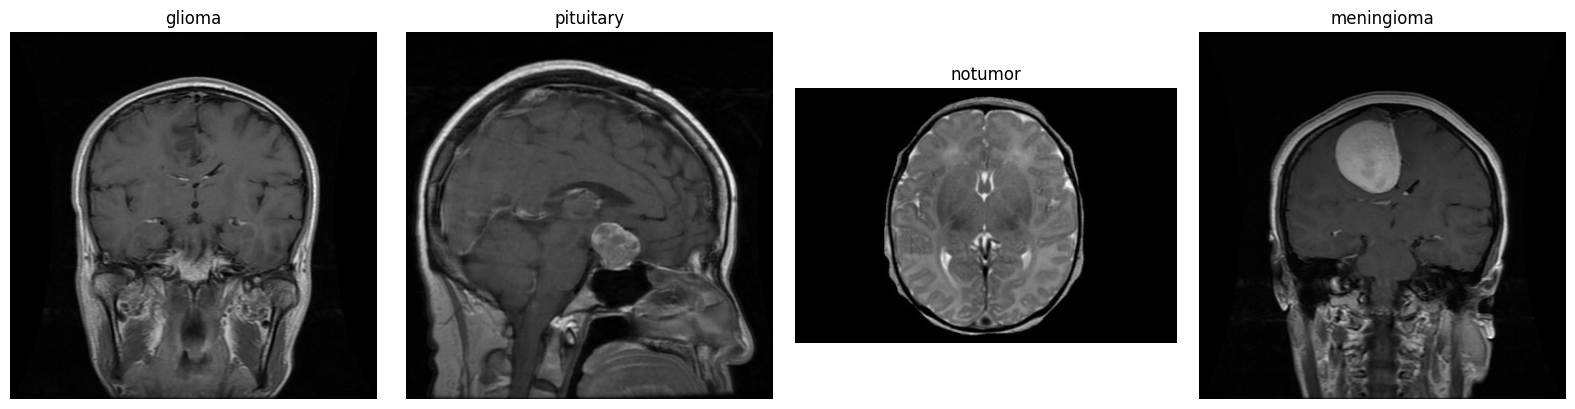

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import os

base_path = '/content/data/Training'
classes = os.listdir(base_path)

fig, axes = plt.subplots(1, len(classes), figsize=(16, 4))

for ax, cls in zip(axes, classes):
    cls_path = os.path.join(base_path, cls)
    sample_img_name = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, sample_img_name))
    ax.imshow(img, cmap='gray')
    ax.set_title(cls)
    ax.axis('off')

plt.tight_layout()
plt.show()

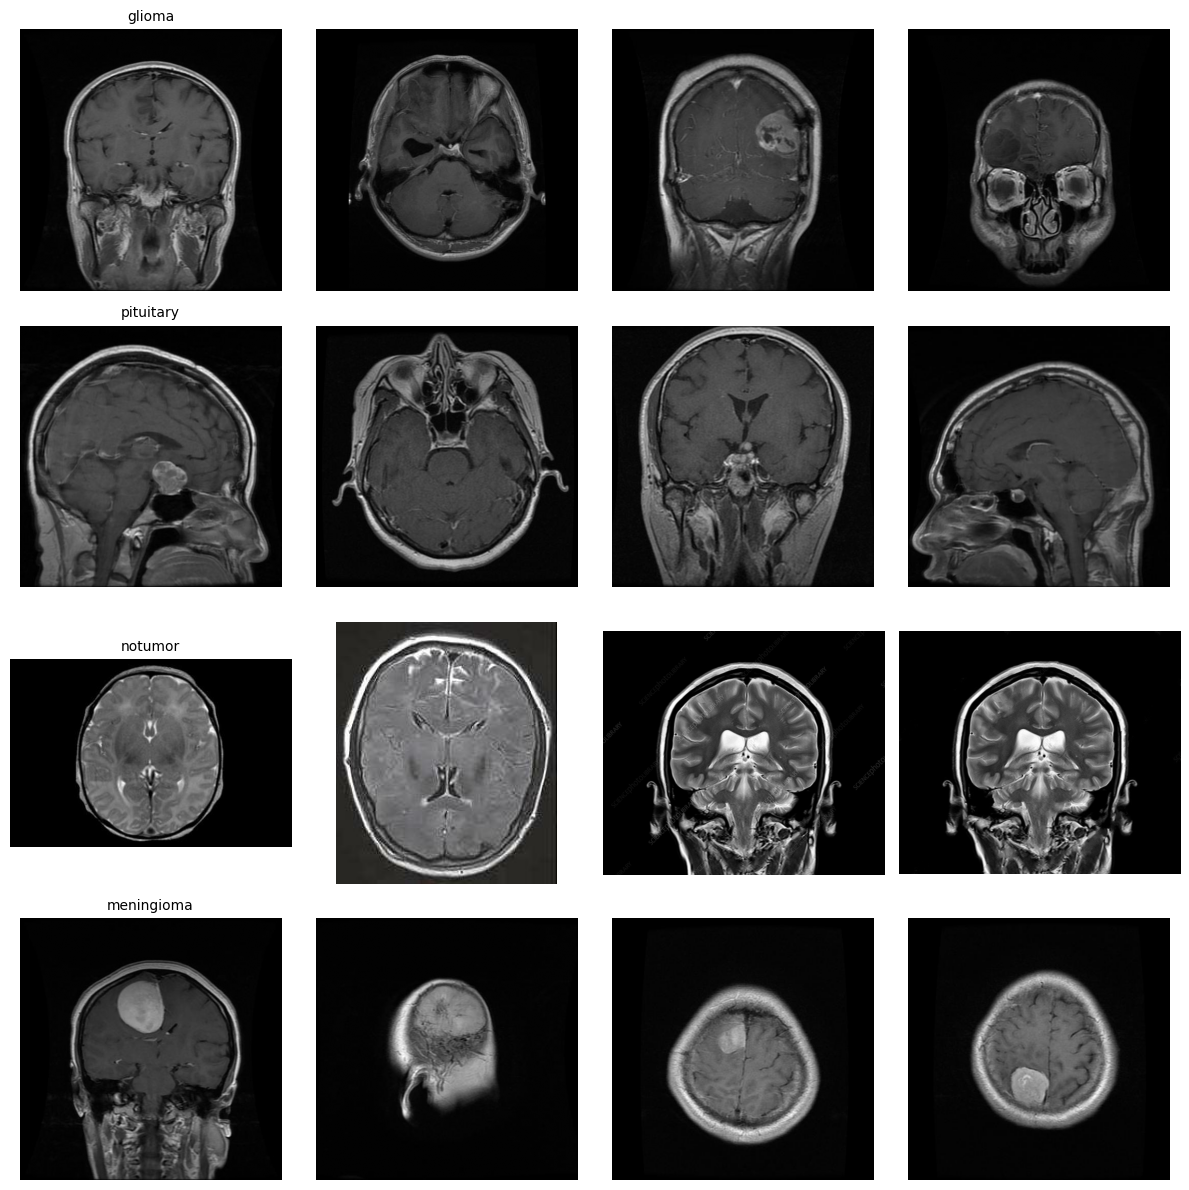

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import os

base_path = '/content/data/Training'
classes = os.listdir(base_path)
n_samples = 4

fig, axes = plt.subplots(len(classes), n_samples, figsize=(12, 12))

for i, cls in enumerate(classes):
    cls_path = os.path.join(base_path, cls)
    sample_names = os.listdir(cls_path)[:n_samples]
    for j, img_name in enumerate(sample_names):
        img = Image.open(os.path.join(cls_path, img_name))
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(cls if j == 0 else '', fontsize=10)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [7]:
import os
from PIL import Image

base_path = '/content/data/Training'
classes = os.listdir(base_path)

sizes = set()
modes = set()

for cls in classes:
    cls_path = os.path.join(base_path, cls)
    for img_name in os.listdir(cls_path)[:50]:
        img = Image.open(os.path.join(cls_path, img_name))
        sizes.add(img.size)
        modes.add(img.mode)

print("Unique image sizes found:", sizes)
print("Unique image modes found:", modes)

Unique image sizes found: {(600, 519), (207, 243), (416, 512), (420, 280), (214, 236), (206, 244), (442, 442), (624, 607), (800, 693), (275, 301), (208, 217), (550, 664), (236, 236), (232, 217), (200, 252), (512, 512), (236, 309), (685, 681), (416, 395), (355, 452), (289, 354), (1338, 1304), (215, 234), (300, 168), (276, 326), (359, 449), (201, 244), (192, 192), (428, 417), (295, 394), (225, 259), (228, 221), (411, 501), (150, 198), (468, 444), (343, 367), (313, 393), (504, 540), (225, 225), (262, 308), (724, 851), (227, 222), (350, 393)}
Unique image modes found: {'L', 'RGB'}


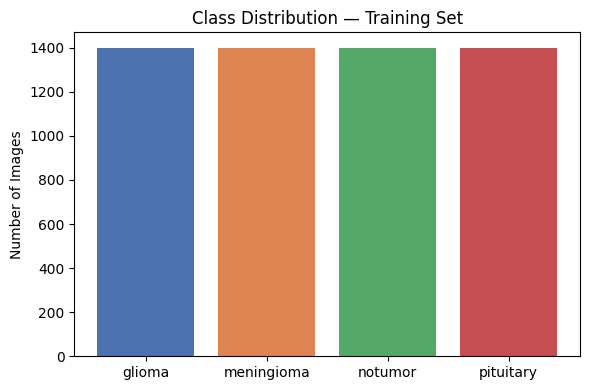

In [8]:
import matplotlib.pyplot as plt

classes_list = ['glioma', 'meningioma', 'notumor', 'pituitary']
counts = [1400, 1400, 1400, 1400]

plt.figure(figsize=(6, 4))
plt.bar(classes_list, counts, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.title('Class Distribution — Training Set')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150)
plt.show()